In [1]:
import numpy as np
import matplotlib.pyplot as plt
import h5py as h5

In [ ]:
BASE_PATH   = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns'
BNS_PATH    = BASE_PATH + '/bns/networks/'
NSBH_PATH   = BASE_PATH + '/bhns/networks/'
OUTPUT_FILE = BASE_PATH + 'bns_nsbh_fisher_gaussians.h5'

import sys

SAMPLER_DIR = (BASE_PATH + '/CE_STM_CBC/pop_models/stellar_mass/'
               'injection_sampler_v2')
EOS_DIR = SAMPLER_DIR + '/sfho_compose_files'

# drop any copy imported from another sampler version earlier in this kernel
sys.modules.pop('generate_tidal_params_correct', None)
sys.path.insert(0, SAMPLER_DIR)

import generate_tidal_params_correct as gtp
from generate_tidal_params_correct import LambdaCalculator, MSUN_GEOM, TOV_RTOL

assert gtp.__file__.startswith(SAMPLER_DIR), f'wrong module: {gtp.__file__}'
print(f'module: {gtp.__file__}')

# 1000 TOV solves at rtol=1e-6, takes a few minutes; build once and reuse
calc = LambdaCalculator(EOS_DIR, method='interp', mmin=1.0)
print(f'TOV max mass: {calc.eos_max_mass:.4f} Msun')
print(f'Lambda(1.4):   {calc.get_lambda(1.4):.2f}')

In [30]:
path = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v3_z_0.5_10_years/pop_m_FP4_spin_NS_fref_5.0_z_MD_lmr_130_BNS_29K_samples_v3_z_0.5_10_years.h5'
file = h5.File(path)

In [31]:
lam1 = file['lambda_1']
lam2 = file['lambda_2']
mass1 = file['mass_1_source']
mass2 = file['mass_2_source']

In [32]:
# Check if any value is practically zero
l1_zero = np.any(np.isclose(lam1, 0, atol=1e-10))
l2_zero = np.any(np.isclose(lam2, 0, atol=1e-10))
print(l1_zero, l2_zero)

False False


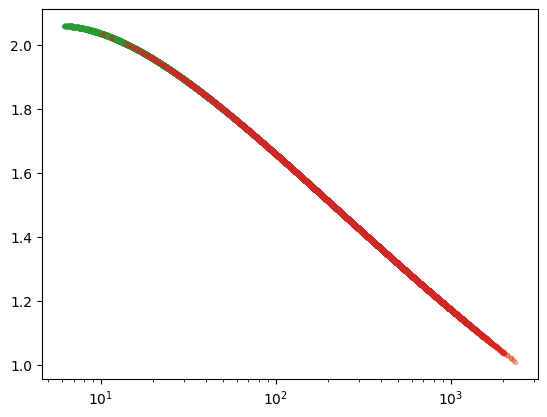

In [34]:
plt.scatter(lam1, mass1, s=10, alpha=0.2)
plt.scatter(lam2, mass2, s=10, alpha=0.2)
plt.scatter(calc.get_lambda(mass1[:]), mass1, s=10, alpha=0.2)
plt.scatter(calc.get_lambda(mass2[:]), mass2, s=10, alpha=0.2)
plt.xscale('log')

In [35]:
path = '/ligo/home/ligo.org/sanika.khadkikar/Projects/stm/post_processing_ns/CE_STM_CBC/pop_models/stellar_mass/injection_sampler_v3_z_0.5_10_years/pop_m_FP4_spin_AGU_fref_5.0_z_MD_lmr_130_NSBH_12K_samples_v3_z_0.5_10_years.h5'
file = h5.File(path)
lam1 = file['lambda_1']
lam2 = file['lambda_2']
mass1 = file['mass_1_source']
mass2 = file['mass_2_source']

In [38]:
# Check if any value is practically zero
l1_zero = np.any(np.isclose(lam1, 0, atol=1e-10))
l2_zero = np.any(np.isclose(lam2, 0, atol=1e-10))
l1_all_zero = np.allclose(lam1, 0)
print(l1_zero, l2_zero, l1_all_zero)

True False True


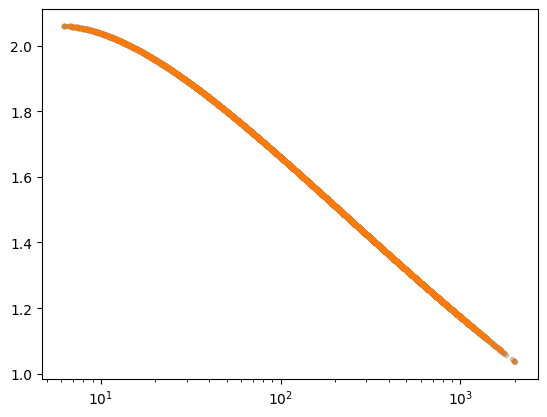

In [40]:
# plt.scatter(lam1, mass1, s=10, alpha=0.2)
plt.scatter(lam2, mass2, s=10, alpha=0.2)
# plt.scatter(calc.get_lambda(mass1[:]), mass1, s=10, alpha=0.2)
plt.scatter(calc.get_lambda(mass2[:]), mass2, s=10, alpha=0.2)
plt.xscale('log')